text embeddings using different different techniques


In [33]:
# loading the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# for unzippping
import zipfile

In [34]:
# unzipping the data
with zipfile.ZipFile('/content/TestReviews.csv.zip','r') as zip_file:
   zip_file.extractall('/content/')

In [35]:
# loading the data
df = pd.read_csv('/content/TestReviews.csv')

In [36]:
df

,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1
...,...,...
4316,My wife and I caught this show at the Golden N...,0
4317,This was the dumbest show we have ever seen. ...,0
4318,My girlfriend and I went to this show. It was ...,0
4319,The restrooms looked like after an bombardment...,0


In [37]:
df.shape

(4321, 2)

In [38]:
# quick analysis of the all data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  4321 non-null   object
 1   class   4321 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 67.6+ KB


In [39]:
df.isna().sum()

,0
review,0
class,0


In [40]:
df.duplicated().sum()

np.int64(173)

In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.shape

(4148, 2)

In [44]:
df.sample(5)

,review,class
704,"On a glorious day in the month of May , my lov...",1
7,My favorite bar in town love the live music an...,1
1820,There is something special about being able to...,1
1396,Jabari wings are the best wings in Charlotte. ...,1
2188,When I first heard there was going to be a new...,1


In [45]:
df['class'].value_counts()

,count
class,
1,2862
0,1286


In [46]:
# now since i am practicing and not focuing on acccuracy i would surely remove some postive reviews so that i would have same class balance and balaced_data
# but i could use the techniques like upsampling or downsampling or use smote

In [47]:
df[df['class']==1] = df[df['class'] == 1].sample(1286)

In [48]:
df['class'].value_counts()

,count
class,
1.0,1286
0.0,1286


In [49]:
df.shape

(4148, 2)

In [50]:
df.dropna(inplace=True)

In [51]:
df.reset_index(drop=True,inplace=True)

In [53]:
df.shape

(2572, 2)

In [54]:
df

,review,class
0,"Love, love, love the calamari. It's so good an...",1.0
1,"Love this place. Stiff martinis and cocktails,...",1.0
2,It's everything a great cocktail bar should be...,1.0
3,"I came here before a pirates game, so it was a...",1.0
4,Olive or Twist is the historic site of my VERY...,1.0
...,...,...
2567,My wife and I are late 30s-early 40s and did n...,0.0
2568,My wife and I caught this show at the Golden N...,0.0
2569,This was the dumbest show we have ever seen. ...,0.0
2570,My girlfriend and I went to this show. It was ...,0.0


Text preprocessing and cleaning

In [56]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)

    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [68]:
df['cleaned_review'].sample(10).values

array(['serious snooze fest waste time nothing mentally visually engaging desert botanical garden visit young child appreciation cactus glass bad salsa definitely bring date like nothing else city liked butterfly shrug',
       'great service friendly staff great food great price ask small town breakfast place definitely back',
       'bosa donut boast best donut ive ever good cannot eat one far softest tastiest donut around',
       'dont usually write review bad one question place dive bar sport bar lounge one side pool table liquor store whatever case happy hour cheap drink thats plus 1 star food good there nothing special caprese salad could make 18 price better ingredient ambiance blah smokey home would entertaining blonde bartender wont let get word recommend flag someone else good luck check 10 end night anyone served anything',
       'disappointing say least looking forward wine friend conversation little nosh artwalkwhat got surprisingly poor customer service became downright

In [57]:
# creating the word cloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['cleaned_review']))

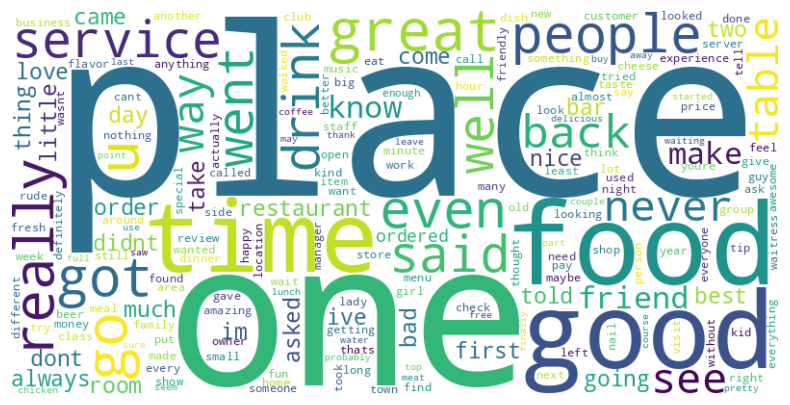

In [58]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [59]:
# word clouds for negative and postive
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['class'] == 0]['cleaned_review']))
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['class'] == 1]['cleaned_review']))

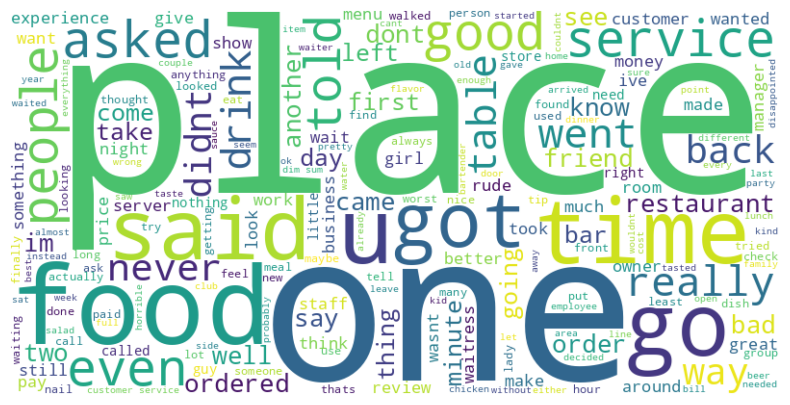

In [61]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.show()


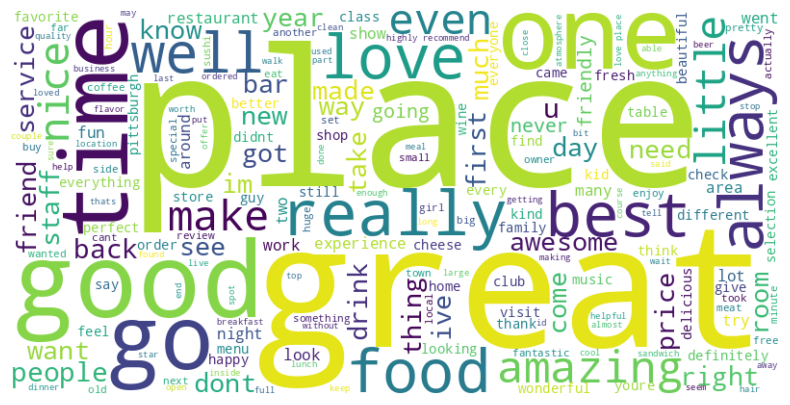

In [62]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.show()

In [69]:
# applying bag of words and machine learning algo like random forest to classify between the positive or negative
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [70]:
cv = CountVectorizer(max_features=5000)
X = cv.fit_transform(df['cleaned_review']).toarray()
y = df['class']

In [71]:
# trian test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# model builidng
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

# prediction
y_pred = rf.predict(X_test)

In [72]:
# interpreting the model performance
accuracy = accuracy_score(y_test,y_pred)
confusion = confusion_matrix(y_test,y_pred)
classification_rep = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy}')
print(f'Confusion Matrix : {confusion}')
print(f'Classification Report : {classification_rep}')

Accuracy : 0.8757281553398059
Confusion Matrix : [[216  31]
 [ 33 235]]
Classification Report :               precision    recall  f1-score   support

         0.0       0.87      0.87      0.87       247
         1.0       0.88      0.88      0.88       268

    accuracy                           0.88       515
   macro avg       0.88      0.88      0.88       515
weighted avg       0.88      0.88      0.88       515



In [75]:
# now applying n grams
ngram = CountVectorizer(max_features=5000,ngram_range=(1,3))
ngram_X = ngram.fit_transform(df['cleaned_review']).toarray()

# ngram model
ngram_X_train,ngram_X_test,ngram_y_train,ngram_y_test = train_test_split(ngram_X,y,test_size=0.2,random_state=0)
ngram_model = RandomForestClassifier(n_estimators=100,random_state=42)
ngram_model.fit(ngram_X_train,ngram_y_train)
ngram_y_pred = ngram_model.predict(ngram_X_test)

In [77]:
# interpreting the model
ngram_accuracy = accuracy_score(ngram_y_test,ngram_y_pred)
ngram_confusion = confusion_matrix(ngram_y_test,ngram_y_pred)
ngram_classification_rep = classification_report(ngram_y_test,ngram_y_pred)

print(f'Accuracy : {ngram_accuracy}')
print(f'Confusion Matrix : {ngram_confusion}')
print(f'Classification Report : {ngram_classification_rep}')

Accuracy : 0.8776699029126214
Confusion Matrix : [[230  31]
 [ 32 222]]
Classification Report :               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88       261
         1.0       0.88      0.87      0.88       254

    accuracy                           0.88       515
   macro avg       0.88      0.88      0.88       515
weighted avg       0.88      0.88      0.88       515



In [79]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.1 MB/s eta 0:00:00


In [80]:
# now word2vec
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [83]:
# applying word2vec
nltk.download('punkt_tab')
tokenized_reviews = [word_tokenize(review) for review in df['cleaned_review']]
word2vec_model = Word2Vec(sentences=tokenized_reviews,vector_size=100,window=5,min_count=1,workers=4)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [88]:
# validating the word2vec model
def get_average_word2vec(tokens,model,num_features):
   valid_words = [word for word in tokens if word in model.wv]
   if not valid_words or len(valid_words) == 0 :
      return np.zeros(num_features)

   vectors = [model.wv[word] for word in valid_words]
   return np.mean(vectors,axis=0)

x_w2v = np.array([get_average_word2vec(tokens,word2vec_model,100) for tokens in tokenized_reviews])
y = df['class']

x_train_w2v,x_test_w2v,y_train,y_test = train_test_split(x_w2v,y,test_size=0.2,random_state=0)

rf_w2v = RandomForestClassifier(n_estimators=500,random_state=0)
rf_w2v.fit(x_train_w2v,y_train)

y_pred_w2v = rf_w2v.predict(x_test_w2v)
print(classification_report(y_test,y_pred_w2v))

              precision    recall  f1-score   support

         0.0       0.70      0.63      0.66       261
         1.0       0.65      0.72      0.69       254

    accuracy                           0.67       515
   macro avg       0.68      0.67      0.67       515
weighted avg       0.68      0.67      0.67       515

